In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Z-score

In [4]:
df=pd.read_csv("placement (1).csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


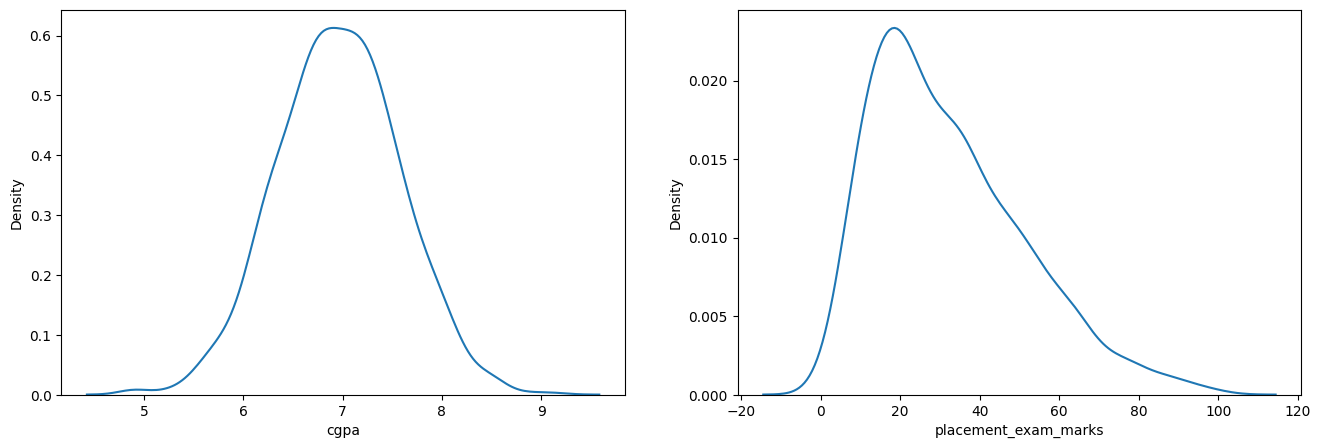

In [5]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])

plt.show()

In [6]:
# We will only work on cgpa as z-score work perfectly for normal distribution

In [7]:
print("Mean of cgpa",df['cgpa'].mean())
print("std of cgpa",df['cgpa'].std())
print("Min value in cgpa",df['cgpa'].min())
print("Max value in cgpa",df['cgpa'].max())

Mean of cgpa 6.96124
std of cgpa 0.6158978751323896
Min value in cgpa 4.89
Max value in cgpa 9.12


In [8]:
# ================== APPROACH 1 ====================================

In [9]:
# Finding the boundary 
print("Higher bound",df['cgpa'].mean()+3*df['cgpa'].std())
print("Lower bound",df['cgpa'].mean()-3*df['cgpa'].std())

Higher bound 8.808933625397168
Lower bound 5.113546374602832


In [10]:
# The outliers
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [11]:
new_df=df[(df['cgpa']<8.80) & (df['cgpa']>5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [12]:
# ========== APPROACH 2 ==========================
#  ========= APPLYING Z-SCORE ==============================

In [13]:
df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()
df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [14]:
df[(df['cgpa_zscore']<-3) | (df['cgpa_zscore']>3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [15]:
#Trimming
new_df=df[(df['cgpa_zscore']<3) & (df['cgpa_zscore']>-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [16]:
# ================  CAPPING  ==========================

In [17]:
upper_limit=df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit=df['cgpa'].mean()-3*df['cgpa'].std()

In [18]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,   
    upper_limit,
    np.where(                              # If value<lower_limit 
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [19]:
df.shape

(1000, 4)

In [20]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00


In [21]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

# Using IQR method

In [23]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

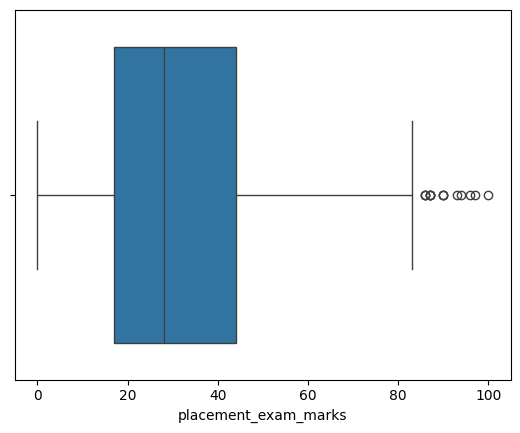

In [24]:
sns.boxplot(x=df['placement_exam_marks'])

In [25]:
# Finding IQR
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [26]:
print(percentile25)

17.0


In [27]:
print(percentile75)

44.0


In [28]:
iqr=percentile75-percentile25
print(iqr)

27.0


In [29]:
upper_limit=percentile75 + 1.5*iqr
lower_limit=percentile25 - 1.5*iqr

In [30]:
print(upper_limit)

84.5


In [31]:
print(lower_limit)

-23.5


In [32]:
# Finding outliers
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.280667
40,6.60,86.0,1,-0.586526
61,7.51,86.0,0,0.890992
134,6.33,93.0,0,-1.024910
162,7.80,90.0,0,1.361849
283,7.09,87.0,0,0.209061
290,8.38,87.0,0,2.303564
311,6.97,87.0,1,0.014223
324,6.64,90.0,0,-0.521580
630,6.56,96.0,1,-0.651472


In [33]:
# ==============   Trimming  ==================
new_df=df[df['placement_exam_marks']<upper_limit]
new_df.shape

(985, 4)

C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\3121895335.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\3121895335.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks'>

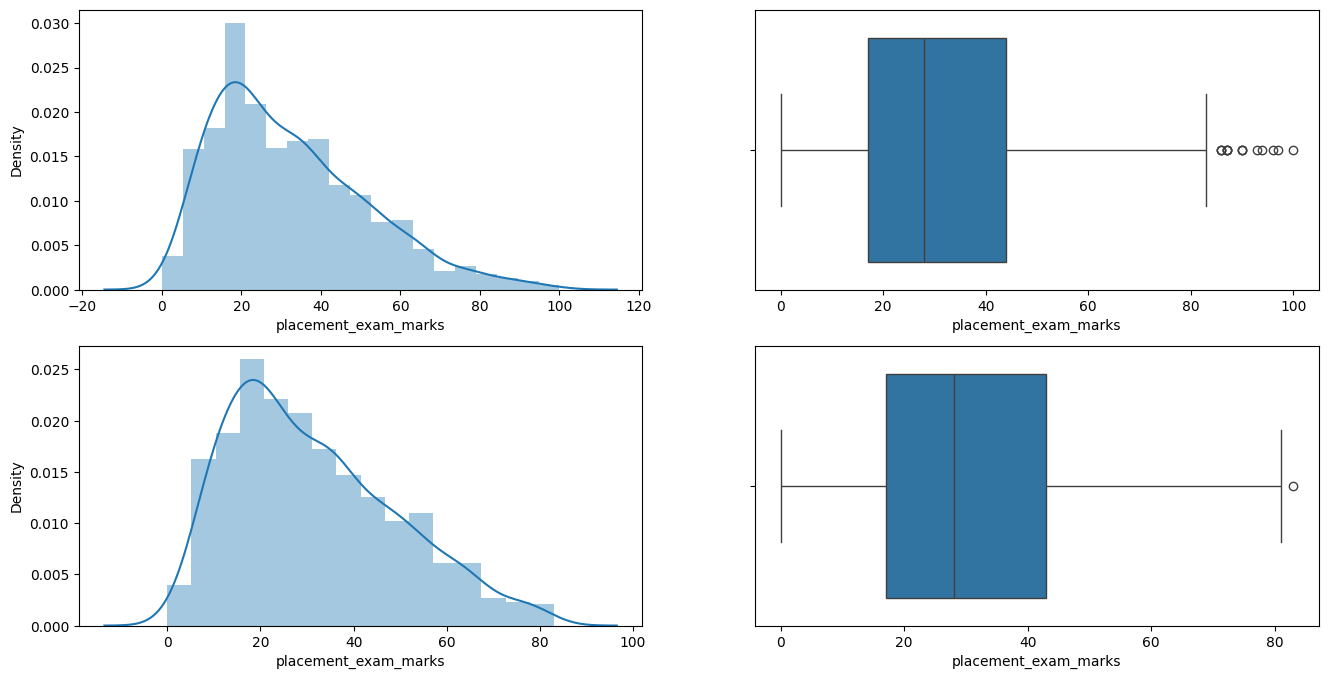

In [34]:
# Comparing using various graph

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df['placement_exam_marks'])

In [35]:
# ==============  Capping ====================

In [36]:
new_df_copy=df.copy()

new_df_copy['placement_exam_marks']=np.where(
    new_df_copy['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_copy['placement_exam_marks']<lower_limit,
        lower_limit,
        new_df_copy['placement_exam_marks']
    )
)

In [37]:
new_df_copy.shape

(1000, 4)

C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\214346202.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\214346202.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_copy['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks'>

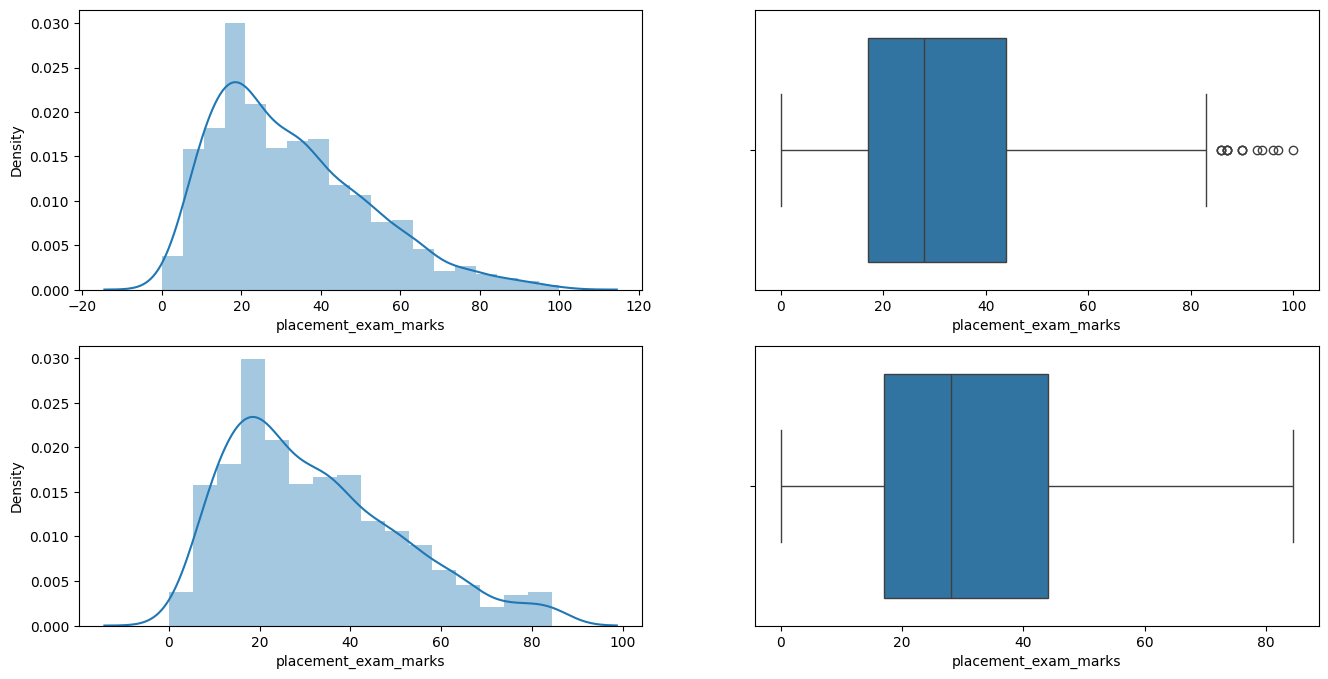

In [38]:
# Comparing using various graph

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_copy['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df_copy['placement_exam_marks'])

# using percentile method

In [77]:
df=pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [79]:
 df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

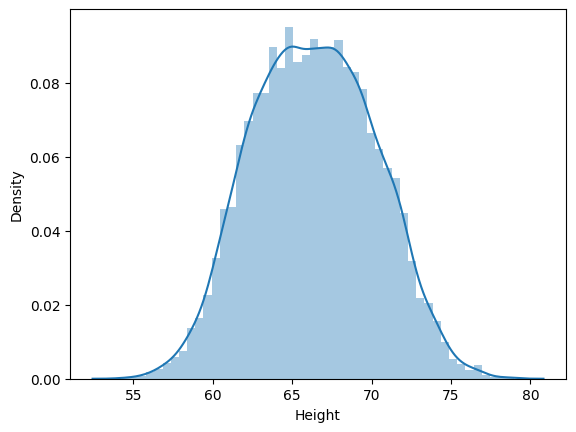

In [81]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

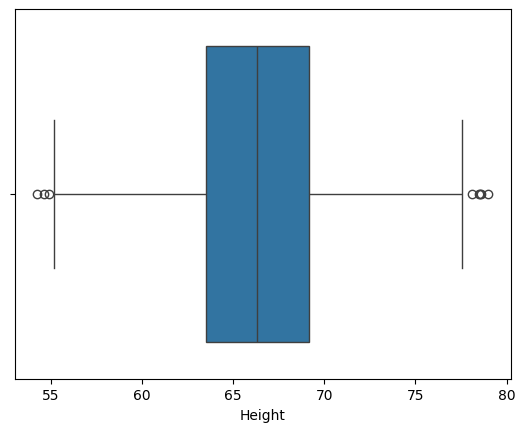

In [83]:
sns.boxplot(x=df['Height'])

In [123]:
# ======  Using trimming  ===================

upper_limit=df['Height'].quantile(0.99)
lower_limit=df['Height'].quantile(0.01)
print(upper_limit)
print(lower_limit)

74.78571507648495
58.134495462372655


In [125]:
df[(df['Height']>=upper_limit) | (df['Height']<=lower_limit)]

,Gender,Height,Weight
23,Male,74.785790,228.761781
190,Male,74.785790,235.035419
197,Male,74.785790,231.924749
202,Male,74.785790,224.124271
215,Male,74.785790,232.635403
...,...,...,...
9761,Female,58.134412,90.341784
9825,Female,58.134412,85.417534
9895,Female,58.134412,93.652957
9904,Female,58.134412,101.202551


In [127]:
new_df= df[(df['Height']<=74.78) & (df['Height']>=58.13)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

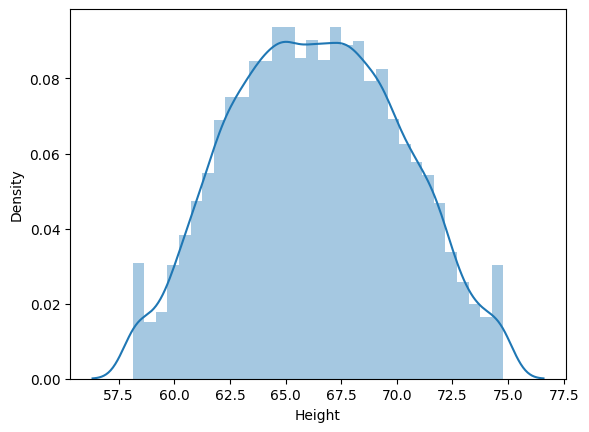

In [129]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

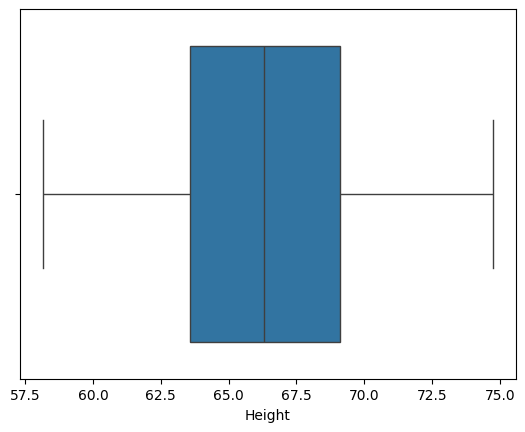

In [101]:
sns.boxplot(x=new_df['Height'])

In [107]:
# ========= using capping -> Winsorization  ====================

In [109]:
df['Height']=np.where(
    df['Height']>=upper_limit,
    upper_limit,
    np.where(
        df['Height']<=lower_limit,
        lower_limit,
        df['Height']
    )
)

In [111]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

C:\Users\Isha\AppData\Local\Temp\ipykernel_16600\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

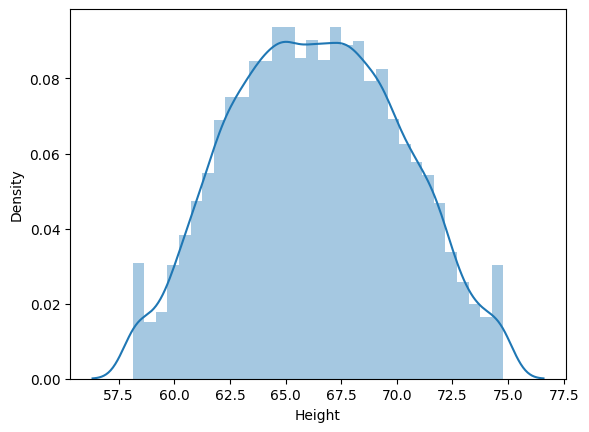

In [117]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

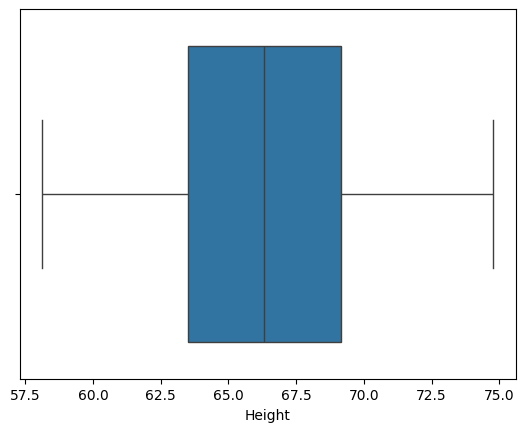

In [121]:
sns.boxplot(x=df['Height'])